# POD validation on a parameterised toy problem

This notebook validates the snapshot-based Proper Orthogonal Decomposition
pipeline before it is applied to discrete particle-system data.

The workflow is:

1. Generate parameterised full-order snapshots.
2. Assemble the snapshot matrix.
3. Compute its singular value decomposition.
4. Construct truncated POD bases.
5. Measure reconstruction accuracy.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pymor
import scipy
import torch

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("PyTorch:", torch.__version__)
print("pyMOR:", pymor.__version__)

FIGURE_DIR = Path("../results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


NumPy: 1.26.4
SciPy: 1.17.1
PyTorch: 2.2.2
pyMOR: 2025.2.2


In [2]:
def full_order_solution(x: np.ndarray, mu: float) -> np.ndarray:
    """Return a parameterised spatial field."""
    return (
        np.sin(np.pi * x)
        + mu * np.sin(2.0 * np.pi * x)
        + mu**2 * np.cos(3.0 * np.pi * x)
    )


n_space = 200
n_snapshots = 41

x = np.linspace(0.0, 1.0, n_space)
parameters = np.linspace(0.0, 2.0, n_snapshots)

# Each column is one full-order solution.
snapshot_matrix = np.column_stack(
    [full_order_solution(x, mu) for mu in parameters]
)

print("Snapshot matrix shape:", snapshot_matrix.shape)

Snapshot matrix shape: (200, 41)


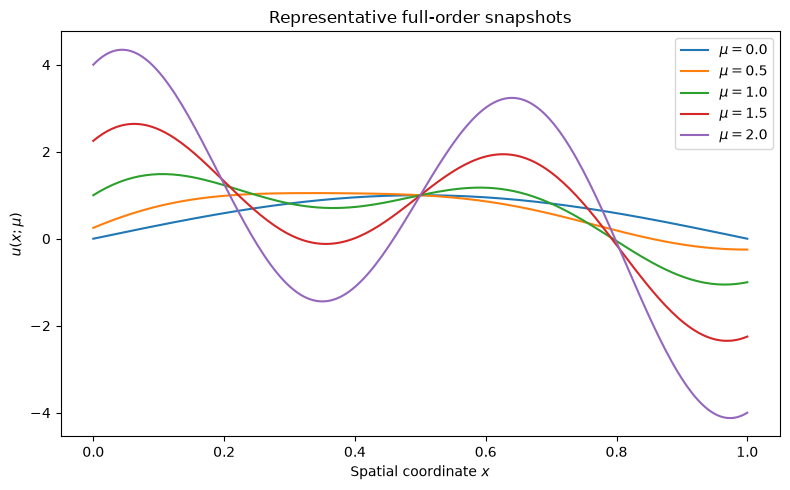

In [3]:
plt.figure(figsize=(8, 5))

for index in [0, 10, 20, 30, 40]:
    plt.plot(
        x,
        snapshot_matrix[:, index],
        label=fr"$\mu={parameters[index]:.1f}$",
    )

plt.xlabel("Spatial coordinate $x$")
plt.ylabel(r"$u(x;\mu)$")
plt.title("Representative full-order snapshots")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
U, singular_values, V_transpose = np.linalg.svd(
    snapshot_matrix,
    full_matrices=False,
)

print("U shape:", U.shape)
print("Singular values shape:", singular_values.shape)
print("V transpose shape:", V_transpose.shape)
print("First six singular values:")
print(singular_values[:6])

U shape: (200, 41)
Singular values shape: (41,)
V transpose shape: (41, 41)
First six singular values:
[1.14109831e+02 4.05763607e+01 9.02155857e+00 1.55660169e-14
 9.62340636e-15 7.82207856e-15]


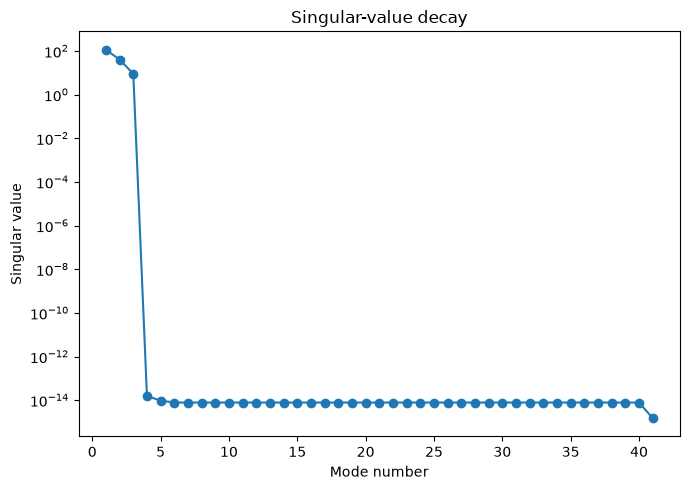

In [5]:
mode_numbers = np.arange(1, singular_values.size + 1)

plt.figure(figsize=(7, 5))
plt.semilogy(mode_numbers, singular_values, marker="o")
plt.xlabel("Mode number")
plt.ylabel("Singular value")
plt.title("Singular-value decay")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "toy_singular_value_decay.pdf",
    bbox_inches="tight",
)
plt.show()

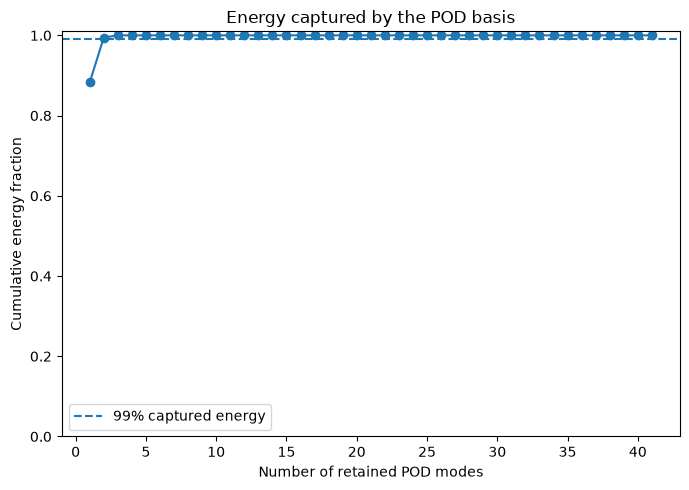

Modes required for 99% energy: 2


In [6]:
energy_fraction = np.cumsum(singular_values**2) / np.sum(
    singular_values**2
)

plt.figure(figsize=(7, 5))
plt.plot(mode_numbers, energy_fraction, marker="o")
plt.axhline(0.99, linestyle="--", label="99% captured energy")
plt.xlabel("Number of retained POD modes")
plt.ylabel("Cumulative energy fraction")
plt.title("Energy captured by the POD basis")
plt.ylim(0.0, 1.01)
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "toy_cumulative_energy.pdf",
    bbox_inches="tight",
)
plt.show()

rank_99 = int(np.searchsorted(energy_fraction, 0.99) + 1)
print("Modes required for 99% energy:", rank_99)

In [7]:
rank = 3

pod_basis = U[:, :rank]
reduced_coefficients = pod_basis.T @ snapshot_matrix
reconstructed_snapshots = pod_basis @ reduced_coefficients

relative_error = (
    np.linalg.norm(snapshot_matrix - reconstructed_snapshots)
    / np.linalg.norm(snapshot_matrix)
)

print(f"Rank-{rank} relative reconstruction error: {relative_error:.3e}")

Rank-3 relative reconstruction error: 5.567e-16


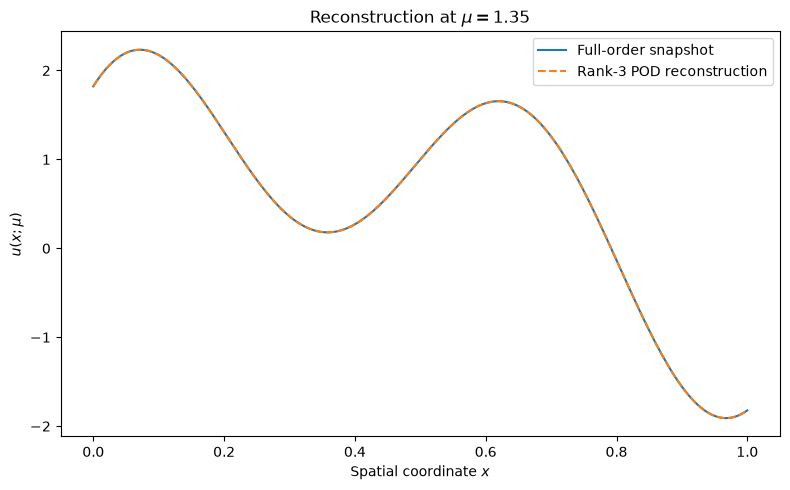

In [8]:
snapshot_index = 27

plt.figure(figsize=(8, 5))
plt.plot(
    x,
    snapshot_matrix[:, snapshot_index],
    label="Full-order snapshot",
)
plt.plot(
    x,
    reconstructed_snapshots[:, snapshot_index],
    linestyle="--",
    label=f"Rank-{rank} POD reconstruction",
)

plt.xlabel("Spatial coordinate $x$")
plt.ylabel(r"$u(x;\mu)$")
plt.title(
    rf"Reconstruction at $\mu={parameters[snapshot_index]:.2f}$"
)
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "toy_snapshot_reconstruction.pdf",
    bbox_inches="tight",
)
plt.show()

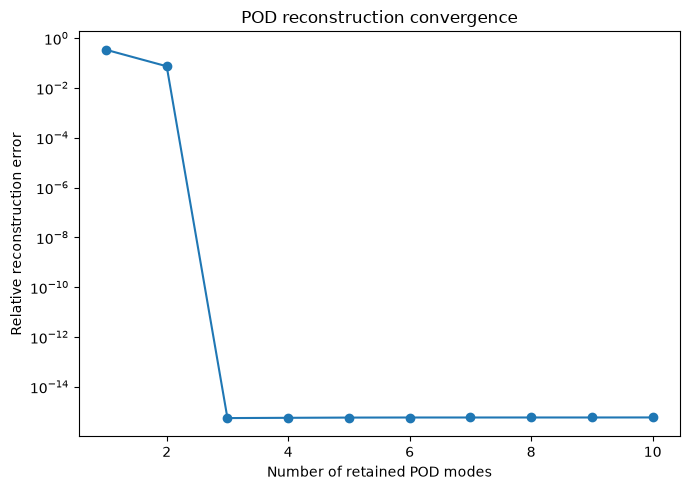

In [9]:
maximum_rank = 10
ranks = np.arange(1, maximum_rank + 1)
errors = []

for current_rank in ranks:
    basis = U[:, :current_rank]
    coefficients = basis.T @ snapshot_matrix
    reconstruction = basis @ coefficients

    error = (
        np.linalg.norm(snapshot_matrix - reconstruction)
        / np.linalg.norm(snapshot_matrix)
    )
    errors.append(error)

plt.figure(figsize=(7, 5))
plt.semilogy(ranks, errors, marker="o")
plt.xlabel("Number of retained POD modes")
plt.ylabel("Relative reconstruction error")
plt.title("POD reconstruction convergence")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "toy_reconstruction_error.pdf",
    bbox_inches="tight",
)
plt.show()

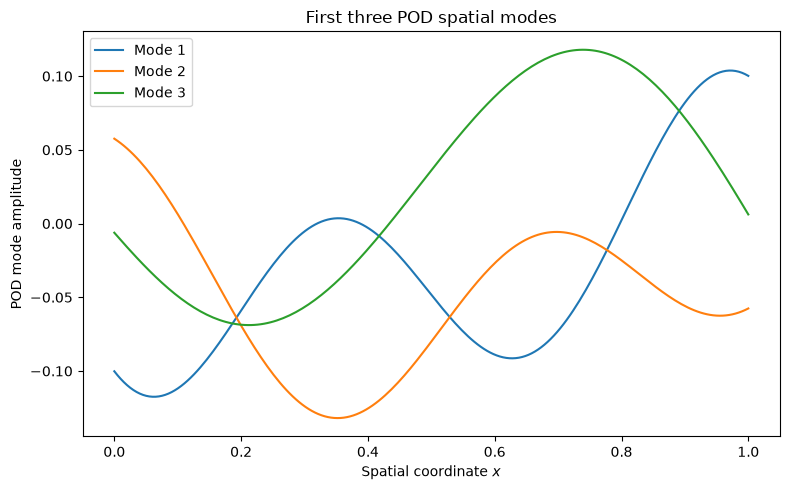

In [13]:
plt.figure(figsize=(8, 5))

for mode_index in range(3):
    plt.plot(
        x,
        U[:, mode_index],
        label=f"Mode {mode_index + 1}",
    )

plt.xlabel("Spatial coordinate $x$")
plt.ylabel("POD mode amplitude")
plt.title("First three POD spatial modes")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "toy_pod_modes.pdf",
    bbox_inches="tight",
)
plt.show()

## Interpretation

The snapshot matrix has numerical rank three. This is expected because every
snapshot is constructed from three fixed spatial functions, with the parameter
changing only their coefficients.

The first two POD modes capture more than 99% of the snapshot energy, although
a rank-two reconstruction still has a noticeable relative error. Retaining the
third mode reduces the reconstruction error to approximately machine precision.

This verifies that the snapshot assembly, singular value decomposition,
POD basis construction and reconstruction calculations are implemented
correctly. The same workflow can now be applied to more complicated data.